# A题问题3：首次导通分位数—最低填充量

第三问要求在微构体导通概率不低于 90% 的前提下，求介质 A 的最低填充量，并将体积分数精确到百分号后两位。

本 Notebook 承接前两问：第一问提供真实裁剪几何、GJK 和并查集导通判定；第二问确定 iid 均匀随机模型。第三问利用导通事件对圆柱数量的单调性，将概率约束反问题转化为“首次导通圆柱数”的 90% 分位数估计。

## 1. 整数优化模型与体积换算

设放入前 (N) 根完整介质 A 后的导通概率为 (P_N)，则

\[
N_{90}=\min\{N\in\mathbb N:P_N\ge0.90\},\qquad
\phi_N=100\%\frac{N\pi(30)^2(5000)}{10000^3}.
\]

计算阶段先搜索整数 (N_{90})，最后才对 (phi_{N_{90}}) 作十进制四舍五入。周期裁剪只改变几何位置，不重复计算一根原圆柱的填充体积。

In [9]:
import math
import numpy as np

BOUNDARY_VOLUME = 10000.0**3
CYLINDER_VOLUME = math.pi * 30.0**2 * 5000.0
VOLUME_STEP_PERCENT = 100.0 * CYLINDER_VOLUME / BOUNDARY_VOLUME
TARGET_PROBABILITY = 0.90
N_MAX = 707
NO_HIT_SENTINEL = N_MAX + 1

print(f"单根介质A体积：{CYLINDER_VOLUME:.6f} nm³")
print(f"每增加一根圆柱，名义体积分数增加：{VOLUME_STEP_PERCENT:.10f}%")
print(f"第三问初始搜索上界：N_max={N_MAX}（哨兵{NO_HIT_SENTINEL}表示超过上界仍未导通）")

单根介质A体积：14137166.941154 nm³
每增加一根圆柱，名义体积分数增加：0.0014137167%
第三问初始搜索上界：N_max=707（哨兵708表示超过上界仍未导通）


## 2. 与第二问完全一致的随机及边界模型

圆柱轴中点在 ([-5000,5000)^3) 内 iid 均匀，轴方向在单位球面上 iid 各向同性。完整圆柱先按周期规则搬运，再与基本盒求交；所有非空真实裁剪碎片分别作为图节点。同源碎片不自动合并，裁剪后不再使用周期镜像距离。

In [10]:
from dataclasses import dataclass
from itertools import combinations, product
import math
import time

import numpy as np
import pandas as pd
from scipy.optimize import minimize

BOX_HALF = 5000.0
BOX_MIN = np.full(3, -BOX_HALF)
BOX_MAX = np.full(3, BOX_HALF)
PERIOD = np.full(3, 2.0 * BOX_HALF)
LENGTH = 5000.0
RADIUS = 30.0
THRESHOLD = 1.8
NUM_TOL = 1e-5
FEAS_TOL = 2e-7
SUPPORT_FEAS_TOL = 1e-9
CONTACT_LIMIT = THRESHOLD + NUM_TOL
SUPPORT_STABILITY_NM = 1e-5
NEAR_THRESHOLD_TOL = 1e-4
GJK_GAP_TOL = 1e-5
GJK_FAR_GUARD = 1e-2

## 3. 真实裁剪碎片的纯原问题支持函数

碎片严格定义为有限圆柱和立方体的交集。支持函数直接求三变量 SLSQP 原问题，并把候选投影恢复到严格可行域；不使用短圆柱替代、胶囊、多面体或对偶证书。

In [11]:
class DynamicUnionFind:
    def __init__(self):
        self.parent = []
        self.rank = []

    def add(self):
        index = len(self.parent)
        self.parent.append(index)
        self.rank.append(0)
        return index

    def find(self, x):
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]
            x = self.parent[x]
        return x

    def union(self, a, b):
        a, b = self.find(a), self.find(b)
        if a == b:
            return False
        if self.rank[a] < self.rank[b]:
            a, b = b, a
        self.parent[b] = a
        if self.rank[a] == self.rank[b]:
            self.rank[a] += 1
        return True

    def connected(self, a, b):
        return self.find(a) == self.find(b)


class Cylinder:
    def __init__(self, p, q, radius=RADIUS):
        self.p = np.asarray(p, float)
        self.q = np.asarray(q, float)
        self.radius = float(radius)
        v = self.q - self.p
        self.length = float(np.linalg.norm(v))
        if self.length <= 1e-12:
            raise ValueError("cylinder axis must have positive length")
        self.u = v / self.length
        self.center = 0.5 * (self.p + self.q)
        self.h = 0.5 * self.length
        extent = self.h * np.abs(self.u) + self.radius * np.sqrt(np.maximum(0.0, 1.0-self.u**2))
        self.aabb_min = self.center - extent
        self.aabb_max = self.center + extent

    def translated(self, shift):
        return Cylinder(self.p + shift, self.q + shift, self.radius)

    def support(self, direction):
        d = np.asarray(direction, float)
        axial = float(d @ self.u)
        radial = d - axial * self.u
        radial_norm = float(np.linalg.norm(radial))
        point = self.center + (self.h if axial >= 0 else -self.h) * self.u
        if radial_norm > 1e-14:
            point = point + self.radius * radial / radial_norm
        return point


def orthobasis(u):
    u = np.asarray(u, float)
    helper = np.eye(3)[int(np.argmin(np.abs(u)))]
    v = np.cross(u, helper)
    v /= np.linalg.norm(v)
    w = np.cross(u, v)
    return np.column_stack((u, v, w))


def axis_segment_in_box(cylinder, lo, hi):
    t0, t1 = -cylinder.h, cylinder.h
    for j in range(3):
        uj = float(cylinder.u[j])
        if abs(uj) <= 1e-14:
            if not (lo[j]-1e-8 <= cylinder.center[j] <= hi[j]+1e-8):
                return None
            continue
        a = (lo[j] - cylinder.center[j]) / uj
        b = (hi[j] - cylinder.center[j]) / uj
        t0, t1 = max(t0, min(a,b)), min(t1, max(a,b))
        if t0 > t1 + 1e-8:
            return None
    if t1-t0 <= 1e-8:
        return None
    return cylinder.center+t0*cylinder.u, cylinder.center+t1*cylinder.u


def normalized_geometry(cylinder, lo, hi):
    q = orthobasis(cylinder.u)
    matrix = q @ np.diag([cylinder.h, cylinder.radius, cylinder.radius])
    scale = np.maximum(hi-lo, 1.0)
    a = np.vstack((matrix/scale[:,None], -matrix/scale[:,None]))
    b = np.r_[(hi-cylinder.center)/scale, (cylinder.center-lo)/scale]
    return matrix, a, b


def y_violation(cylinder, matrix, y, lo, hi):
    x = cylinder.center + matrix @ y
    axial = max(0.0, abs(float(y[0]))-1.0) * cylinder.h
    radial = max(0.0, float(np.linalg.norm(y[1:]))-1.0) * cylinder.radius
    box = max(0.0, float(np.max(lo-x)), float(np.max(x-hi)))
    return max(axial, radial, box)


def dykstra_start(y,a,b,cycles=20):
    """Project a y-point onto bounds, radial disk and box half-spaces."""
    projectors=[
        lambda z:np.clip(z,-1.0,1.0),
        lambda z:np.r_[z[0],z[1:]/max(1.0,float(np.linalg.norm(z[1:])))],
    ]
    for row,rhs in zip(a,b):
        denominator=float(row@row)
        projectors.append(
            lambda z,row=row,rhs=rhs,denominator=denominator:
                z-max(0.0,float(row@z-rhs))/denominator*row
        )
    point=np.asarray(y,float).copy()
    corrections=[np.zeros(3) for _ in projectors]
    for _ in range(cycles):
        for index,project in enumerate(projectors):
            shifted=point+corrections[index]
            updated=project(shifted)
            corrections[index]=shifted-updated
            point=updated
    return point


def recover_feasible_y(cylinder,matrix,a,b,y,tolerance=SUPPORT_FEAS_TOL):
    """Return a strictly feasible primal point, or None if projection stalls."""
    point=np.asarray(y,float).copy()
    if y_violation(cylinder,matrix,point,BOX_MIN,BOX_MAX)<=tolerance:
        return point
    for cycles in (20,100,500,1500):
        point=dykstra_start(point,a,b,cycles=cycles)
        if y_violation(cylinder,matrix,point,BOX_MIN,BOX_MAX)<=tolerance:
            return point
    return None


def cylinder_box_feasible(cylinder, lo, hi):
    if np.any(cylinder.aabb_max < lo-1e-9) or np.any(cylinder.aabb_min > hi+1e-9):
        return None
    segment = axis_segment_in_box(cylinder, lo, hi)
    if segment is not None:
        return 0.5*(segment[0]+segment[1])

    matrix, a, b = normalized_geometry(cylinder, lo, hi)
    closest = np.clip(cylinder.center, lo, hi)
    y0 = np.linalg.solve(matrix, closest-cylinder.center)
    y0[0] = np.clip(y0[0], -1.0, 1.0)
    radial = np.linalg.norm(y0[1:])
    if radial > 1.0:
        y0[1:] /= radial
    constraints = [
        {"type":"ineq", "fun":lambda y: b-a@y, "jac":lambda y: -a},
        {"type":"ineq", "fun":lambda y: 1-y[1]**2-y[2]**2,
         "jac":lambda y: np.array([0.0,-2*y[1],-2*y[2]])},
    ]
    starts = [y0, np.zeros(3)]
    for start in starts:
        result = minimize(
            lambda y: 0.5*float(np.dot(y-start,y-start)), start,
            jac=lambda y: y-start, method="SLSQP", bounds=[(-1,1)]*3,
            constraints=constraints, options={"ftol":1e-10,"maxiter":300},
        )
        y = result.x
        if y_violation(cylinder, matrix, y, lo, hi) <= FEAS_TOL:
            return cylinder.center + matrix@y
    return None


class Fragment:
    def __init__(self, parent_id, integer_shift, cylinder, feasible_point):
        self.parent_id = int(parent_id)
        self.integer_shift = tuple(int(x) for x in integer_shift)
        self.cylinder = cylinder
        self.center = 0.5*(np.maximum(cylinder.aabb_min,BOX_MIN)+np.minimum(cylinder.aabb_max,BOX_MAX))
        self.aabb_min = np.maximum(cylinder.aabb_min, BOX_MIN)
        self.aabb_max = np.minimum(cylinder.aabb_max, BOX_MAX)
        self.matrix, self.a, self.b = normalized_geometry(cylinder, BOX_MIN, BOX_MAX)
        initial_feasible_y=np.linalg.solve(self.matrix,feasible_point-cylinder.center)
        recovered_feasible_y=recover_feasible_y(
            cylinder,self.matrix,self.a,self.b,initial_feasible_y
        )
        self.feasible_y=(
            recovered_feasible_y if recovered_feasible_y is not None
            else initial_feasible_y
        )
        if y_violation(cylinder,self.matrix,self.feasible_y,BOX_MIN,BOX_MAX)>FEAS_TOL:
            raise RuntimeError("fragment has no numerically feasible seed point")
        self.cache = {}
        self.optimized_calls = 0
        self.solver_fallbacks = 0
        self.stability_accepts = 0
        self.dykstra_retries = 0
        self.projection_recoveries = 0

    def clear_support_cache(self):
        self.cache.clear()

    def support(self, direction):
        d = np.asarray(direction,float)
        norm = float(np.linalg.norm(d))
        if norm <= 1e-14:
            return self.cylinder.center+self.matrix@self.feasible_y
        d /= norm
        # Use the normalized direction itself as the key.  Rounding a direction
        # close to an axial sign change can incorrectly reuse the opposite cap.
        key = tuple(float(value) for value in d)
        if key in self.cache:
            return self.cache[key].copy()
        analytic = self.cylinder.support(d)
        if np.all(analytic >= BOX_MIN-SUPPORT_FEAS_TOL) and np.all(analytic <= BOX_MAX+SUPPORT_FEAS_TOL):
            self.cache[key] = analytic.copy()
            return analytic
        p = self.matrix.T@d
        objective_scale=max(float(np.linalg.norm(p)),1.0)
        p /= objective_scale
        start = np.zeros(3)
        start[0] = 1.0 if p[0]>=0 else -1.0
        rn = np.linalg.norm(p[1:])
        if rn>0: start[1:] = p[1:]/rn
        constraints = [
            {"type":"ineq","fun":lambda y:self.b-self.a@y,"jac":lambda y:-self.a},
            {"type":"ineq","fun":lambda y:1-y[1]**2-y[2]**2,
             "jac":lambda y:np.array([0.0,-2*y[1],-2*y[2]])},
        ]
        candidates=[]

        def solve_from(initial,ftol,maxiter,source):
            result=minimize(lambda y:-float(p@y),initial,jac=lambda y:-p,
                            method="SLSQP",bounds=[(-1,1)]*3,constraints=constraints,
                            options={"ftol":ftol,"maxiter":maxiter})
            recovered=recover_feasible_y(
                self.cylinder,self.matrix,self.a,self.b,result.x
            )
            if recovered is not None:
                if np.linalg.norm(recovered-result.x)>1e-12:
                    self.projection_recoveries += 1
                candidates.append((float(p@recovered),recovered,result.success,source))
            return bool(result.success and recovered is not None)

        first_success=solve_from(start,1e-10,300,"extreme")
        if not first_success:
            self.solver_fallbacks += 1
            solve_from(self.feasible_y,1e-12,1000,"feasible")
            box_start=np.linalg.solve(
                self.matrix,
                np.clip(analytic,BOX_MIN,BOX_MAX)-self.cylinder.center,
            )
            solve_from(np.clip(box_start,-1.0,1.0),1e-12,1000,"box")
            projected_start=dykstra_start(start,self.a,self.b,cycles=50)
            solve_from(projected_start,1e-12,1000,"dykstra")
            self.dykstra_retries += 1

            if len(candidates)<2:
                extra_starts=(
                    np.zeros(3),
                    -start,
                    0.5*(self.feasible_y+start),
                    0.5*(self.feasible_y+np.clip(box_start,-1.0,1.0)),
                )
                for extra_index,extra_start in enumerate(extra_starts):
                    solve_from(extra_start,1e-12,1500,f"extra_{extra_index}")
                self.dykstra_retries += len(extra_starts)

        if not candidates:
            raise RuntimeError("fragment support produced no strictly feasible primal candidate")
        best=max(candidates,key=lambda z:z[0])
        _,y,success,_=best
        if not first_success:
            other_values=sorted(
                (candidate[0] for candidate in candidates if candidate is not best),
                reverse=True,
            )
            support_spread_nm=(best[0]-other_values[0])*objective_scale if other_values else math.inf
            if support_spread_nm<=SUPPORT_STABILITY_NM:
                self.stability_accepts += 1
                success=True
        self.optimized_calls += 1
        if not success:
            raise RuntimeError(
                "fragment support remained unresolved after retry; "
                f"strict objectives/status={[(value, ok, source) for value, _, ok, source in candidates]}"
            )
        point=self.cylinder.center+self.matrix@y
        if y_violation(self.cylinder,self.matrix,y,BOX_MIN,BOX_MAX)>SUPPORT_FEAS_TOL:
            raise RuntimeError("support point lost strict primal feasibility")
        self.cache[key]=point.copy()
        return point


def fragment_shift_ranges(cylinder):
    lower=np.ceil((cylinder.aabb_min-BOX_MAX)/PERIOD-1e-12).astype(int)
    upper=np.floor((cylinder.aabb_max-BOX_MIN)/PERIOD+1e-12).astype(int)
    return [range(int(lower[j]),int(upper[j])+1) for j in range(3)]


def generate_parent_fragments(parent_id, cylinder):
    fragments=[]
    for k in product(*fragment_shift_ranges(cylinder)):
        k=np.asarray(k,int)
        shifted=cylinder.translated(-k*PERIOD)
        feasible=cylinder_box_feasible(shifted,BOX_MIN,BOX_MAX)
        if feasible is not None:
            fragments.append(Fragment(parent_id,k,shifted,feasible))
    return fragments

## 4. AABB、GJK 与并查集导通判定

AABB和轴段距离只负责安全粗筛，最终候选使用真实裁剪碎片 GJK。最短距离不超过1.8 nm时合并并查集；数值未决会明确中止，不能静默记为不导通。

In [12]:
@dataclass
class SupportPoint:
    w: np.ndarray
    a: np.ndarray
    b: np.ndarray


@dataclass
class GJKResult:
    lower: float
    upper: float
    a: np.ndarray
    b: np.ndarray
    status: str


def closest_simplex(simplex):
    points=np.asarray([s.w for s in simplex])
    best=None
    for size in range(1,min(4,len(simplex))+1):
        for ids in combinations(range(len(simplex)),size):
            ids=np.asarray(ids,int); face=points[ids]
            gram=face@face.T
            kkt=np.block([[gram,np.ones((size,1))],[np.ones((1,size)),np.zeros((1,1))]])
            lam=np.linalg.lstsq(kkt,np.r_[np.zeros(size),1.0],rcond=None)[0][:size]
            if np.min(lam)<-1e-9: continue
            lam=np.maximum(lam,0); lam/=lam.sum()
            close=lam@face; value=float(close@close)
            if best is None or value<best[0]: best=(value,ids,lam,close)
    _,ids,lam,close=best
    pa=sum(lam[t]*simplex[idx].a for t,idx in enumerate(ids))
    pb=sum(lam[t]*simplex[idx].b for t,idx in enumerate(ids))
    return close,ids,pa,pb


def gjk(shape_a,shape_b,threshold=THRESHOLD,allow_lower=True,maxiter=100):
    def supp(d):
        a=shape_a.support(d); b=shape_b.support(-np.asarray(d,float))
        return SupportPoint(a-b,a,b)
    direction=shape_b.center-shape_a.center
    if np.linalg.norm(direction)<1e-14: direction=np.array([1.,0,0])
    simplex=[supp(direction)]; lower=0.0; pa=simplex[0].a; pb=simplex[0].b
    for _ in range(maxiter):
        close,active,pa,pb=closest_simplex(simplex)
        simplex=[simplex[i] for i in active]
        upper=float(np.linalg.norm(close))
        if upper<=1e-10: return GJKResult(0,0,pa,pb,"intersect")
        if threshold is not None and upper<=threshold+NUM_TOL: return GJKResult(lower,upper,pa,pb,"connected")
        new=supp(-close)
        lower=max(lower,max(0.0,float(close@new.w/upper)))
        if threshold is not None and allow_lower and lower>threshold+NUM_TOL:
            return GJKResult(lower,upper,pa,pb,"separated")
        duplicate=any(np.linalg.norm(new.w-old.w)<=1e-9 for old in simplex)
        if duplicate or upper-lower<=1e-9*max(1.,upper):
            return GJKResult(lower,upper,pa,pb,"converged")
        simplex.append(new)
    return GJKResult(lower,float(np.linalg.norm(pa-pb)),pa,pb,"maxiter")


def segment_distances_one_to_many(p,q,p2,q2):
    d1=q-p
    d2=q2-p2
    r=p[None,:]-p2
    a=float(d1@d1)
    e=np.einsum('ij,ij->i',d2,d2)
    b=d2@d1
    c=r@d1
    f=np.einsum('ij,ij->i',d2,r)
    denom=a*e-b*b
    s=np.zeros_like(denom)
    np.divide(b*f-c*e,denom,out=s,where=denom>1e-12)
    s=np.clip(s,0,1)
    t=(b*s+f)/e
    low=t<0; high=t>1
    t=np.clip(t,0,1)
    s=np.where(low,np.clip(-c/a,0,1),s)
    s=np.where(high,np.clip((b-c)/a,0,1),s)
    cp1=p[None,:]+s[:,None]*d1
    cp2=p2+t[:,None]*d2
    dist=np.linalg.norm(cp1-cp2,axis=1)
    return dist,s,t,cp1,cp2


def in_box(point):
    return bool(np.all(point>=BOX_MIN-2e-7) and np.all(point<=BOX_MAX+2e-7))


def fragments_connect(a,b,axis_distance,s,t,cp_a,cp_b,stats):
    # 最常见的侧面-侧面情形可直接构造盒内见证点。
    if 1e-9<s<1-1e-9 and 1e-9<t<1-1e-9:
        v=cp_b-cp_a; d=float(axis_distance)
        if d<=2*RADIUS:
            wa=wb=0.5*(cp_a+cp_b)
        else:
            wa=cp_a+RADIUS*v/d
            wb=cp_b-RADIUS*v/d
        if in_box(wa) and in_box(wb):
            if float(np.linalg.norm(wa-wb))<=CONTACT_LIMIT:
                stats['side_witness']+=1
                return True
    stats['full_gjk']+=1
    full=gjk(a.cylinder,b.cylinder,allow_lower=True)
    if full.lower>CONTACT_LIMIT:
        return False
    if full.upper<=CONTACT_LIMIT and in_box(full.a) and in_box(full.b):
        return True
    stats['clipped_gjk']+=1
    clipped=gjk(a,b,allow_lower=False,maxiter=180)
    if clipped.status=="maxiter":
        raise RuntimeError("clipped GJK did not converge")
    if clipped.upper<=CONTACT_LIMIT:
        return True
    gap=abs(clipped.upper-clipped.lower)
    separated=(
        clipped.lower>CONTACT_LIMIT
        and (gap<=GJK_GAP_TOL or min(clipped.lower,clipped.upper)>CONTACT_LIMIT+GJK_FAR_GUARD)
    )
    if abs(clipped.upper-THRESHOLD)<=NEAR_THRESHOLD_TOL or not separated:
        a.clear_support_cache(); b.clear_support_cache()
        clipped=gjk(a,b,allow_lower=False,maxiter=500)
        if clipped.status=="maxiter":
            raise RuntimeError("near-threshold clipped GJK did not converge")
        stats['near_threshold']+=1
        if clipped.upper<=CONTACT_LIMIT:
            return True
        gap=abs(clipped.upper-clipped.lower)
        separated=(
            clipped.lower>CONTACT_LIMIT
            and (gap<=GJK_GAP_TOL or min(clipped.lower,clipped.upper)>CONTACT_LIMIT+GJK_FAR_GUARD)
        )
        if not separated:
            raise RuntimeError(
                "clipped GJK remained numerically unresolved: "
                f"lower={clipped.lower}, upper={clipped.upper}"
            )
    return False

## 5. 首次导通数量 (T)

固定一串 iid 圆柱，逐根完整激活。必须加入第 (N) 根原圆柱的全部裁剪碎片后，才检查左右电极是否同根。定义

\[
T=\min\{N:\text{加入前 }N\text{ 根后首次导通}\}.
\]

由于导通事件随 (N) 单调，(P_N=P(T\le N))，故 (N_{90}) 就是 (T) 的总体90%分位数。707根仍不导通用哨兵708表示右删失。

In [13]:
def sample_cylinders(n,rng):
    centers=rng.uniform(-BOX_HALF,BOX_HALF,size=(n,3))
    directions=rng.normal(size=(n,3))
    directions/=np.linalg.norm(directions,axis=1,keepdims=True)
    p=centers-0.5*LENGTH*directions
    q=centers+0.5*LENGTH*directions
    return [Cylinder(p[i],q[i]) for i in range(n)]


def simulate_nested(seed,n_levels=np.array([354,424,495,707]),base_seed=20260808):
    seed_sequence=np.random.SeedSequence([int(base_seed),int(seed)])
    rng=np.random.Generator(np.random.PCG64(seed_sequence))
    cylinders=sample_cylinders(int(n_levels[-1]),rng)
    dsu=DynamicUnionFind(); left=dsu.add(); right=dsu.add()
    capacity=8*int(n_levels[-1])
    mins=np.empty((capacity,3)); maxs=np.empty((capacity,3))
    ps=np.empty((capacity,3)); qs=np.empty((capacity,3))
    fragments=[]; indicators=np.zeros(len(n_levels),dtype=bool)
    stats={'fragments':0,'aabb_candidates':0,'axis_candidates':0,'side_witness':0,
           'full_gjk':0,'clipped_gjk':0,'support_calls':0,'fallbacks':0,
           'dykstra_retries':0,'projection_recoveries':0,
           'stability_accepts':0,'near_threshold':0}
    level=0
    left_slab_min=BOX_MIN.copy(); left_slab_max=BOX_MAX.copy(); left_slab_max[0]=BOX_MIN[0]+CONTACT_LIMIT
    right_slab_min=BOX_MIN.copy(); right_slab_min[0]=BOX_MAX[0]-CONTACT_LIMIT; right_slab_max=BOX_MAX.copy()

    for parent_id,cylinder in enumerate(cylinders):
        for frag in generate_parent_fragments(parent_id,cylinder):
            node=dsu.add(); m=len(fragments)
            if frag.aabb_min[0]<=left_slab_max[0]+1e-10 and cylinder_box_feasible(frag.cylinder,left_slab_min,left_slab_max) is not None:
                dsu.union(left,node)
            if frag.aabb_max[0]>=right_slab_min[0]-1e-10 and cylinder_box_feasible(frag.cylinder,right_slab_min,right_slab_max) is not None:
                dsu.union(right,node)
            if m:
                gap=np.maximum(0.0,np.maximum(frag.aabb_min-maxs[:m],mins[:m]-frag.aabb_max))
                ids=np.flatnonzero(np.einsum('ij,ij->i',gap,gap)<=CONTACT_LIMIT**2+1e-12)
                stats['aabb_candidates']+=len(ids)
                if len(ids):
                    dist,s,t,cpa,cpb=segment_distances_one_to_many(frag.cylinder.p,frag.cylinder.q,ps[ids],qs[ids])
                    keep=np.flatnonzero(dist<=2*RADIUS+CONTACT_LIMIT+1e-10)
                    stats['axis_candidates']+=len(keep)
                    for pos in keep:
                        old_id=int(ids[pos])
                        if dsu.connected(node,old_id+2):
                            continue
                        if fragments_connect(frag,fragments[old_id],dist[pos],s[pos],t[pos],cpa[pos],cpb[pos],stats):
                            dsu.union(node,old_id+2)
            fragments.append(frag)
            mins[m]=frag.aabb_min; maxs[m]=frag.aabb_max
            ps[m]=frag.cylinder.p; qs[m]=frag.cylinder.q

        count=parent_id+1
        if dsu.connected(left,right):
            indicators[level:]=True
            stats['fragments']=len(fragments)
            stats['support_calls']=sum(f.optimized_calls for f in fragments)
            stats['fallbacks']=sum(f.solver_fallbacks for f in fragments)
            stats['dykstra_retries']=sum(f.dykstra_retries for f in fragments)
            stats['projection_recoveries']=sum(f.projection_recoveries for f in fragments)
            stats['stability_accepts']=sum(f.stability_accepts for f in fragments)
            return indicators,stats
        while level<len(n_levels) and count==n_levels[level]:
            indicators[level]=dsu.connected(left,right)
            level+=1
    stats['fragments']=len(fragments)
    stats['support_calls']=sum(f.optimized_calls for f in fragments)
    stats['fallbacks']=sum(f.solver_fallbacks for f in fragments)
    stats['dykstra_retries']=sum(f.dykstra_retries for f in fragments)
    stats['projection_recoveries']=sum(f.projection_recoveries for f in fragments)
    stats['stability_accepts']=sum(f.stability_accepts for f in fragments)
    return indicators,stats


def simulate_nested_checked(seed,n_levels=np.array([354,424,495,707]),base_seed=20260808):
    try:
        return simulate_nested(seed,n_levels,base_seed)
    except Exception as exc:
        raise RuntimeError(f"Monte Carlo trial {seed} failed") from exc


def run_monte_carlo(trial_count,n_levels=np.array([354,424,495,707]),base_seed=20260808,n_jobs=1,trial_start=0):
    """固定试验数；每个试验用独立、可复现的(seed, trial_index)随机流。"""
    trial_indices=list(range(int(trial_start),int(trial_start)+int(trial_count)))
    started=time.perf_counter()
    if n_jobs==1:
        outputs=[]
        report_every=max(1,int(trial_count)//10)
        for trial_index in trial_indices:
            try:
                outputs.append(simulate_nested_checked(trial_index,n_levels,base_seed))
            except Exception as exc:
                raise RuntimeError(f"蒙特卡洛第{trial_index}次试验失败") from exc
            local_count=trial_index-int(trial_start)+1
            if local_count%report_every==0 or local_count==trial_count:
                print(f"完成 {local_count}/{trial_count} 次试验")
    else:
        from joblib import Parallel,delayed
        outputs=Parallel(n_jobs=n_jobs,backend="loky")(
            delayed(simulate_nested_checked)(i,n_levels,base_seed) for i in trial_indices
        )
    indicators=np.asarray([item[0] for item in outputs],dtype=bool)
    diagnostics=pd.DataFrame([item[1] for item in outputs])
    assert np.all(indicators[:,:-1]<=indicators[:,1:]), "共同前缀的导通结果违反单调性。"
    return indicators,diagnostics,time.perf_counter()-started


def wilson_interval(successes,trials,z=1.959963984540054):
    successes=np.asarray(successes,float)
    n=float(trials)
    p=successes/n
    denominator=1+z*z/n
    center=(p+z*z/(2*n))/denominator
    radius=z*np.sqrt(p*(1-p)/n+z*z/(4*n*n))/denominator
    return np.maximum(0,center-radius),np.minimum(1,center+radius)

In [14]:
SEARCH_LEVELS = np.arange(1, 708, dtype=int)
NO_HIT_SENTINEL = int(SEARCH_LEVELS[-1]) + 1


def simulate_first_passage(seed, max_cylinders=707, base_seed=20260808):
    """Return the first complete parent-cylinder count that connects the box.

    This is intentionally a thin wrapper around the Q2 nested-prefix engine.
    The sentinel ``max_cylinders + 1`` means that no connection was observed
    within the simulated upper bound; it is not an observed connection count.
    """
    max_cylinders = int(max_cylinders)
    levels = (
        SEARCH_LEVELS
        if max_cylinders == int(SEARCH_LEVELS[-1])
        else np.arange(1, max_cylinders + 1, dtype=int)
    )
    indicators, original_stats = simulate_nested_checked(
        int(seed), levels, int(base_seed)
    )
    hits = np.flatnonzero(indicators)
    first_passage = int(hits[0] + 1) if len(hits) else max_cylinders + 1
    reconstructed = levels >= first_passage
    if not np.array_equal(reconstructed, indicators):
        raise AssertionError("first-passage reconstruction violated monotonicity")
    stats = {"activated_cylinders": min(first_passage, max_cylinders)}
    stats.update(original_stats)
    return first_passage, stats


def simulate_first_passage_checked(seed, max_cylinders=707, base_seed=20260808):
    try:
        return simulate_first_passage(seed, max_cylinders, base_seed)
    except Exception as exc:
        raise RuntimeError(
            f"Monte Carlo first-passage trial {seed} failed"
        ) from exc


def run_first_passage_monte_carlo(
    trial_count,
    max_cylinders=707,
    base_seed=20260808,
    n_jobs=1,
    trial_start=0,
):
    """Run reproducible independent trials and return first-passage counts."""
    trial_indices = list(
        range(int(trial_start), int(trial_start) + int(trial_count))
    )
    started = time.perf_counter()
    if int(n_jobs) == 1:
        outputs = []
        report_every = max(1, int(trial_count) // 10)
        for local_index, trial_index in enumerate(trial_indices, start=1):
            outputs.append(
                simulate_first_passage_checked(
                    trial_index, max_cylinders, base_seed
                )
            )
            if local_index % report_every == 0 or local_index == trial_count:
                print(f"completed {local_index}/{trial_count} trials")
    else:
        from joblib import Parallel, delayed

        outputs = Parallel(n_jobs=int(n_jobs), backend="loky")(
            delayed(simulate_first_passage_checked)(
                trial_index, max_cylinders, base_seed
            )
            for trial_index in trial_indices
        )

    first_passage = np.asarray([item[0] for item in outputs], dtype=np.int16)
    diagnostics = pd.DataFrame([item[1] for item in outputs])
    sentinel = int(max_cylinders) + 1
    if np.any((first_passage < 1) | (first_passage > sentinel)):
        raise AssertionError("invalid first-passage count")
    return first_passage, diagnostics, time.perf_counter() - started


def one_sided_wilson(successes, trials, z=1.6448536269514722):
    """Return marginal one-sided Wilson lower and upper bounds."""
    return wilson_interval(successes, trials, z=z)

## 6. 回归检查

In [15]:
# 体积换算与传统四舍五入
assert abs(VOLUME_STEP_PERCENT - 0.001413716694115407) < 1e-15
q2_levels = np.array([354, 424, 495, 707], dtype=int)
assert np.array_equal(
    np.floor(BOUNDARY_VOLUME*np.array([0.005, 0.006, 0.007, 0.01])/CYLINDER_VOLUME + 0.5).astype(int),
    q2_levels,
)

# 各向同性和位置均匀性的矩检验
test_rng = np.random.default_rng(20260808)
test_centers = test_rng.uniform(-BOX_HALF, BOX_HALF, size=(100_000, 3))
test_directions = test_rng.normal(size=(100_000, 3))
test_directions /= np.linalg.norm(test_directions, axis=1, keepdims=True)
assert np.all((test_centers >= BOX_MIN) & (test_centers < BOX_MAX))
assert np.max(np.abs(test_centers.mean(axis=0))) < 30.0
assert np.max(np.abs(test_directions.mean(axis=0))) < 0.01
assert np.max(np.abs((test_directions**2).mean(axis=0) - 1/3)) < 0.01

# 已知有限圆柱表面距离和1.8 nm阈值
test_a = Cylinder(np.array([-50., 0., 0.]), np.array([50., 0., 0.]))
test_b = Cylinder(np.array([-50., 100., 0.]), np.array([50., 100., 0.]))
test_c = Cylinder(np.array([60., 0., 0.]), np.array([160., 0., 0.]))
assert abs(gjk(test_a, test_b, threshold=None).upper - 40.0) < 1e-5
assert abs(gjk(test_a, test_c, threshold=None).upper - 10.0) < 1e-5
at_threshold = Cylinder(
    np.array([-50., 2*RADIUS+THRESHOLD, 0.]),
    np.array([50., 2*RADIUS+THRESHOLD, 0.]),
)
above_threshold = Cylinder(
    np.array([-50., 2*RADIUS+THRESHOLD+5e-4, 0.]),
    np.array([50., 2*RADIUS+THRESHOLD+5e-4, 0.]),
)
assert gjk(test_a, at_threshold, threshold=None).upper <= CONTACT_LIMIT
assert gjk(test_a, above_threshold, threshold=None).upper > CONTACT_LIMIT

# 跨界同源碎片不能仅凭身份自动连接
crossing = Cylinder(np.array([4000., 0., 0.]), np.array([6000., 0., 0.]), radius=30.)
crossing_fragments = generate_parent_fragments(0, crossing)
assert len(crossing_fragments) == 2
test_dsu = DynamicUnionFind()
left_test, right_test = test_dsu.add(), test_dsu.add()
fragment_nodes = [test_dsu.add() for _ in crossing_fragments]
test_dsu.union(left_test, fragment_nodes[0])
test_dsu.union(fragment_nodes[1], right_test)
assert not test_dsu.connected(left_test, right_test)

# 支持点必须属于真实圆柱—盒交集
for fragment in crossing_fragments:
    for direction in np.vstack((np.eye(3), -np.eye(3))):
        point = fragment.support(direction)
        y = np.linalg.solve(fragment.matrix, point-fragment.cylinder.center)
        assert y_violation(fragment.cylinder, fragment.matrix, y, BOX_MIN, BOX_MAX) <= FEAS_TOL

# 首次导通包装器必须精确重构所有前缀状态
test_t, test_stats = simulate_first_passage(0, N_MAX, 20260808)
assert test_t == 314
assert np.array_equal(test_t <= q2_levels, np.array([True, True, True, True]))
assert test_stats["near_threshold"] == 0

# Wilson区间标准值
lo50, hi50 = wilson_interval(50, 100)
assert np.allclose([lo50, hi50], [0.4038315, 0.5961685], atol=1e-5)
print("几何、随机分布、边界碎片和首次导通回归检查通过。")

几何、随机分布、边界碎片和首次导通回归检查通过。


## 7. 正式蒙特卡洛与可复现缓存

每个试验使用 `SeedSequence([20260808, trial_id])` 建立独立 PCG64 随机流，因此结果与串并行调度无关。默认读取正式缓存；从头复算可切换为 `production`，同一数值环境断点续算用 `resume`。

正式缓存同时保存模型哈希、随机流、数值环境、全部几何容差与诊断。前2500个试验使用和第二问相同的随机流，并要求由 (T) 重构的四档布尔值逐比特一致、稳定几何计数一致。SLSQP的投影和多起点重试次数只作数值审计，不要求跨进程批次逐项相等。

In [16]:
from pathlib import Path
import hashlib
import os
import platform
import scipy

BASE_SEED = 20260808
PRODUCTION_TRIALS = 22500
MIN_FORMAL_TRIALS = 22500
QUICK_TRIALS = 20
N_JOBS = 10
BATCH_SIZE = 100
RUN_MODE = "cache"       # "cache"、"quick"、"production" 或 "resume"
CACHE_PATH = Path("q3_first_passage_results.npz")
Q2_CACHE_PATH = Path("q2_mc_results_2500.npz")
EXPECTED_MODEL_CODE_SHA256 = "ed95e324f7c4622d878e2944b209165780dcd0b02e885b65e6ae5b543d106a35"
EXPECTED_Q2_MODEL_SHA256 = "a7cdb15115b2f9757e10d45cc3692d674c3751f82fb39be5fdc91afe653df00e"
EXPECTED_Q2_RESULT_SHA256 = "902fe5bc0a119e1dbeac40f756e5aba149dc0f1ee55de897b50d8d8f434bf7d3"
assert RUN_MODE in {"cache", "quick", "production", "resume"}


def generator_environment_now():
    return {
        "Python": platform.python_version(),
        "NumPy": np.__version__,
        "SciPy": scipy.__version__,
        "RNG": "PCG64",
    }


def save_first_passage_cache(path, first_passage, diagnostics, elapsed_seconds, requested_trials):
    frame = pd.DataFrame(diagnostics)
    temporary = Path(str(path) + ".tmp.npz")
    np.savez_compressed(
        temporary,
        first_passage=np.asarray(first_passage, dtype=np.int16),
        trial_indices=np.arange(len(first_passage), dtype=np.int32),
        diagnostics=frame.to_numpy(dtype=float),
        diagnostic_columns=np.asarray(frame.columns, dtype=str),
        completed_trials=int(len(first_passage)),
        requested_trials=int(requested_trials),
        elapsed_seconds=float(elapsed_seconds),
        base_seed=BASE_SEED,
        n_max=N_MAX,
        no_hit_sentinel=NO_HIT_SENTINEL,
        target_probability=TARGET_PROBABILITY,
        model_code_sha256=EXPECTED_MODEL_CODE_SHA256,
        q2_model_code_sha256=EXPECTED_Q2_MODEL_SHA256,
        q2_indicator_sha256=EXPECTED_Q2_RESULT_SHA256,
        generator_python=platform.python_version(),
        generator_numpy=np.__version__,
        generator_scipy=scipy.__version__,
        bit_generator="PCG64",
        random_stream_schema="SeedSequence([base_seed, trial_index])",
        box_half=BOX_HALF,
        cylinder_length=LENGTH,
        cylinder_radius=RADIUS,
        threshold=THRESHOLD,
        numeric_tolerance=NUM_TOL,
        feasibility_tolerance=FEAS_TOL,
        support_feasibility_tolerance=SUPPORT_FEAS_TOL,
        support_stability_nm=SUPPORT_STABILITY_NM,
        near_threshold_tolerance=NEAR_THRESHOLD_TOL,
        gjk_gap_tolerance=GJK_GAP_TOL,
        gjk_far_guard=GJK_FAR_GUARD,
        contact_limit=CONTACT_LIMIT,
    )
    os.replace(temporary, path)


def load_first_passage_cache(path, require_same_environment=False):
    data = np.load(path, allow_pickle=False)
    assert int(data["base_seed"]) == BASE_SEED
    assert int(data["n_max"]) == N_MAX
    assert int(data["no_hit_sentinel"]) == NO_HIT_SENTINEL
    assert float(data["target_probability"]) == TARGET_PROBABILITY
    assert str(data["model_code_sha256"]) == EXPECTED_MODEL_CODE_SHA256
    assert str(data["q2_model_code_sha256"]) == EXPECTED_Q2_MODEL_SHA256
    assert str(data["q2_indicator_sha256"]) == EXPECTED_Q2_RESULT_SHA256
    assert float(data["threshold"]) == THRESHOLD
    assert float(data["numeric_tolerance"]) == NUM_TOL
    assert float(data["feasibility_tolerance"]) == FEAS_TOL
    assert float(data["support_feasibility_tolerance"]) == SUPPORT_FEAS_TOL
    assert float(data["support_stability_nm"]) == SUPPORT_STABILITY_NM
    assert float(data["near_threshold_tolerance"]) == NEAR_THRESHOLD_TOL
    assert float(data["gjk_gap_tolerance"]) == GJK_GAP_TOL
    assert float(data["gjk_far_guard"]) == GJK_FAR_GUARD
    assert float(data["contact_limit"]) == CONTACT_LIMIT
    first_passage = data["first_passage"].astype(np.int16)
    assert int(data["completed_trials"]) == len(first_passage)
    assert np.array_equal(data["trial_indices"], np.arange(len(first_passage)))
    columns = [str(value) for value in data["diagnostic_columns"]]
    diagnostics = pd.DataFrame(data["diagnostics"], columns=columns)
    assert len(diagnostics) == len(first_passage)
    environment = {
        "Python": str(data["generator_python"]),
        "NumPy": str(data["generator_numpy"]),
        "SciPy": str(data["generator_scipy"]),
        "RNG": str(data["bit_generator"]),
    }
    if require_same_environment:
        assert environment == generator_environment_now(), "resume不允许跨数值环境混合续算"
    return first_passage, diagnostics, float(data["elapsed_seconds"]), environment


if RUN_MODE == "cache":
    if not CACHE_PATH.exists():
        raise FileNotFoundError("第三问正式缓存不存在；可改用quick或production模式。")
    first_passage, trial_diagnostics, elapsed_seconds, generator_environment = load_first_passage_cache(CACHE_PATH)
    assert len(first_passage) >= MIN_FORMAL_TRIALS, "缓存尚未达到预先规定的正式样本量"
elif RUN_MODE == "quick":
    first_passage, trial_diagnostics, elapsed_seconds = run_first_passage_monte_carlo(
        QUICK_TRIALS, N_MAX, BASE_SEED, n_jobs=1
    )
    generator_environment = generator_environment_now()
else:
    if RUN_MODE == "resume" and CACHE_PATH.exists():
        old_t, old_diagnostics, elapsed_seconds, generator_environment = load_first_passage_cache(
            CACHE_PATH, require_same_environment=True
        )
        t_batches = [old_t]
        diagnostic_batches = [old_diagnostics]
        completed = len(old_t)
    else:
        t_batches, diagnostic_batches = [], []
        elapsed_seconds = 0.0
        completed = 0
        generator_environment = generator_environment_now()
    for start in range(completed, PRODUCTION_TRIALS, BATCH_SIZE):
        batch_trials = min(BATCH_SIZE, PRODUCTION_TRIALS-start)
        batch_t, batch_diagnostics, batch_elapsed = run_first_passage_monte_carlo(
            batch_trials, N_MAX, BASE_SEED, N_JOBS, trial_start=start
        )
        t_batches.append(batch_t)
        diagnostic_batches.append(batch_diagnostics)
        elapsed_seconds += batch_elapsed
        first_passage = np.concatenate(t_batches)
        trial_diagnostics = pd.concat(diagnostic_batches, ignore_index=True)
        save_first_passage_cache(
            CACHE_PATH, first_passage, trial_diagnostics, elapsed_seconds, PRODUCTION_TRIALS
        )
        print(f"完成 {len(first_passage)}/{PRODUCTION_TRIALS} 次正式试验")
    first_passage = np.concatenate(t_batches)
    trial_diagnostics = pd.concat(diagnostic_batches, ignore_index=True)

N_TRIALS = len(first_passage)
assert np.all((first_passage >= 1) & (first_passage <= NO_HIT_SENTINEL))
assert np.isfinite(trial_diagnostics.to_numpy(dtype=float)).all()
assert (trial_diagnostics.to_numpy(dtype=float) >= 0).all()
assert int(trial_diagnostics["near_threshold"].sum()) == 0

# 和第二问2500个随机构型进行逐样本及稳定几何计数回归。
# SLSQP的投影/重试次数可能受进程级数值路径影响，只作有限非负诊断，
# 不要求跨批次逐项相等；导通布尔值必须逐比特相等。
if N_TRIALS >= 2500 and Q2_CACHE_PATH.exists():
    q2_cache = np.load(Q2_CACHE_PATH, allow_pickle=False)
    q2_levels = q2_cache["levels"].astype(int)
    reconstructed_q2 = first_passage[:2500, None] <= q2_levels[None, :]
    assert np.array_equal(reconstructed_q2, q2_cache["indicators"].astype(bool))
    q2_result_hash = hashlib.sha256(np.packbits(reconstructed_q2).tobytes()).hexdigest()
    assert q2_result_hash == EXPECTED_Q2_RESULT_SHA256
    q2_columns = [str(value) for value in q2_cache["diagnostic_columns"]]
    # support_calls / fallbacks 受 SLSQP 进程级数值路径影响，不要求跨批次逐项相等
    stable_columns = [
        "fragments", "aabb_candidates", "axis_candidates", "side_witness",
        "full_gjk", "clipped_gjk", "near_threshold",
    ]
    stable_indices = [q2_columns.index(name) for name in stable_columns]
    assert np.array_equal(
        trial_diagnostics.loc[:2499, stable_columns].to_numpy(dtype=float),
        q2_cache["diagnostics"][:, stable_indices],
    )
    # SLSQP-dependent columns: verify they are non-negative (not exact match)
    slsqp_columns = ["support_calls", "fallbacks"]
    slsqp_indices = [q2_columns.index(name) for name in slsqp_columns]
    assert (trial_diagnostics.loc[:2499, slsqp_columns].to_numpy(dtype=float) >= 0).all()
    assert (q2_cache["diagnostics"][:, slsqp_indices] >= 0).all()
    q2_regression = "导通标志逐比特一致，稳定几何计数一致"
else:
    q2_regression = "quick模式未执行完整Q2缓存回归"

result_hash = hashlib.sha256(first_passage.tobytes()).hexdigest()
print(f"载入/完成 {N_TRIALS} 次首次导通试验；记录耗时 {elapsed_seconds:.2f} s")
print(f"结果SHA-256：{result_hash}")
print("与第二问回归：", q2_regression)
print("生成缓存环境：", generator_environment)
print(f"当前读取环境：Python {platform.python_version()} | NumPy {np.__version__} | SciPy {scipy.__version__}")

载入/完成 22500 次首次导通试验；记录耗时 12056.32 s
结果SHA-256：358db028c64e9b57406a8ac1d834b44974a738ee9ebe4d99b13ac4e22ca79bbc
与第二问回归： 导通标志逐比特一致，稳定几何计数一致
生成缓存环境： {'Python': '3.12.12', 'NumPy': '2.3.5', 'SciPy': '1.17.0', 'RNG': 'PCG64'}
当前读取环境：Python 3.12.12 | NumPy 2.3.5 | SciPy 1.17.0


## 8. 经验90%分位数与独立统计验证

点估计为 (\widehat N_{90}=T_{(\lceil0.9M\rceil)})。另外给出固定样本下的非参数次序统计量95%区间。

在独立认证分支中，候选舍入档只由前2500次发现样本冻结，其余样本只用于验证候选档下边界外侧和上边界；另外使用全部样本给出描述性的点估计和分布无关区间。例如0.82%对应所有四舍五入后显示0.82%的整数数量，而不是只验证名义0.82%换算出的单个数量。两个端点分别使用97.5%单侧Clopper–Pearson界，经Bonferroni后联合置信水平至少95%。

In [17]:
from scipy.stats import beta, binom


def phi_percent(count):
    return np.asarray(count, dtype=float) * VOLUME_STEP_PERCENT


def round_half_up_2(value):
    return math.floor(float(value)*100.0 + 0.5 + 1e-12) / 100.0


def clopper_pearson_lower(successes, trials, tail_probability=0.025):
    if successes == 0:
        return 0.0
    return float(beta.ppf(tail_probability, successes, trials-successes+1))


def clopper_pearson_upper(successes, trials, tail_probability=0.025):
    if successes == trials:
        return 1.0
    return float(beta.ppf(1-tail_probability, successes+1, trials-successes))


counts = np.arange(1, N_MAX+1, dtype=int)
successes_curve = np.count_nonzero(first_passage[:, None] <= counts[None, :], axis=0)
probability_curve = successes_curve / N_TRIALS
assert np.all(np.diff(probability_curve) >= 0)
assert probability_curve[-1] >= TARGET_PROBABILITY

quantile_rank = int(math.ceil(TARGET_PROBABILITY*N_TRIALS))
sorted_t = np.sort(first_passage)
n_hat = int(sorted_t[quantile_rank-1])
if n_hat == NO_HIT_SENTINEL:
    raise RuntimeError("90%分位数被右删失；必须扩大N_MAX")
phi_hat = float(phi_percent(n_hat))
reported_hat = round_half_up_2(phi_hat)

# 固定样本下，非参数次序统计量95%分位数区间
order_low = max(1, int(binom.ppf(0.025, N_TRIALS, TARGET_PROBABILITY)))
order_high = min(N_TRIALS, int(binom.ppf(0.975, N_TRIALS, TARGET_PROBABILITY)) + 1)
n_quantile_low = int(sorted_t[order_low-1])
n_quantile_high = int(sorted_t[order_high-1])
if n_quantile_high == NO_HIT_SENTINEL:
    raise RuntimeError("总体N90置信区间上端被右删失；必须扩大N_MAX")
phi_quantile_low = float(phi_percent(n_quantile_low))
phi_quantile_high = float(phi_percent(n_quantile_high))
rounded_quantile_interval = (
    round_half_up_2(phi_quantile_low),
    round_half_up_2(phi_quantile_high),
)
order_rounding_certified = math.isclose(
    rounded_quantile_interval[0], rounded_quantile_interval[1], abs_tol=1e-12
)
order_certified_report = (
    rounded_quantile_interval[0] if order_rounding_certified else math.nan
)

# 2500次发现样本冻结两位小数候选，其余样本独立验证整个舍入档
DISCOVERY_TRIALS = 2500
if N_TRIALS <= DISCOVERY_TRIALS:
    raise RuntimeError("正式验证样本必须独立于2500次发现样本")
discovery_t = first_passage[:DISCOVERY_TRIALS]
validation_t = first_passage[DISCOVERY_TRIALS:]
discovery_rank = int(math.ceil(TARGET_PROBABILITY*DISCOVERY_TRIALS))
n_discovery = int(np.partition(discovery_t, discovery_rank-1)[discovery_rank-1])
candidate_report = round_half_up_2(float(phi_percent(n_discovery)))

rounded_all_counts = np.array([round_half_up_2(phi_percent(n)) for n in counts])
candidate_counts = counts[np.isclose(rounded_all_counts, candidate_report, atol=1e-12)]
if not len(candidate_counts):
    raise RuntimeError("候选两位小数档没有对应整数圆柱数")
candidate_low_n = int(candidate_counts.min())
candidate_high_n = int(candidate_counts.max())
previous_n = candidate_low_n - 1

validation_trials = len(validation_t)
previous_successes = int(np.count_nonzero(validation_t <= previous_n))
candidate_successes = int(np.count_nonzero(validation_t <= candidate_high_n))
previous_probability = previous_successes / validation_trials
candidate_probability = candidate_successes / validation_trials
previous_upper = clopper_pearson_upper(previous_successes, validation_trials, 0.025)
candidate_lower = clopper_pearson_lower(candidate_successes, validation_trials, 0.025)
rounding_bin_certified = (
    previous_upper < TARGET_PROBABILITY
    and candidate_lower >= TARGET_PROBABILITY
)

local_counts = np.unique(np.clip(
    np.r_[n_hat-5:n_hat+6, previous_n, candidate_low_n, candidate_high_n], 1, N_MAX
)).astype(int)
local_successes = successes_curve[local_counts-1]
local_probability = probability_curve[local_counts-1]
local_low, local_high = wilson_interval(local_successes, N_TRIALS)
local_table = pd.DataFrame({
    "圆柱数N": local_counts,
    "实际体积分数/%": phi_percent(local_counts),
    "两位小数显示/%": [round_half_up_2(phi_percent(n)) for n in local_counts],
    "导通次数": local_successes,
    "试验次数": N_TRIALS,
    "经验导通概率": local_probability,
    "边际Wilson 95%下限": local_low,
    "边际Wilson 95%上限": local_high,
})
display(local_table.style.format({
    "实际体积分数/%": "{:.6f}",
    "两位小数显示/%": "{:.2f}",
    "经验导通概率": "{:.4f}",
    "边际Wilson 95%下限": "{:.4f}",
    "边际Wilson 95%上限": "{:.4f}",
}))

validation_table = pd.DataFrame([
    {
        "验证目的": "排除候选舍入档下边界外侧",
        "N": previous_n,
        "实际体积分数/%": phi_percent(previous_n),
        "成功数/样本数": f"{previous_successes}/{validation_trials}",
        "经验概率": previous_probability,
        "97.5%单侧CP界": previous_upper,
        "判据": "上界 < 0.90",
        "是否通过": previous_upper < TARGET_PROBABILITY,
    },
    {
        "验证目的": "确认候选舍入档上边界已达标",
        "N": candidate_high_n,
        "实际体积分数/%": phi_percent(candidate_high_n),
        "成功数/样本数": f"{candidate_successes}/{validation_trials}",
        "经验概率": candidate_probability,
        "97.5%单侧CP界": candidate_lower,
        "判据": "下界 ≥ 0.90",
        "是否通过": candidate_lower >= TARGET_PROBABILITY,
    },
])
display(validation_table.style.format({
    "实际体积分数/%": "{:.6f}",
    "经验概率": "{:.4f}",
    "97.5%单侧CP界": "{:.4f}",
}))

summary_table = pd.DataFrame([{
    "总试验数": N_TRIALS,
    "经验N90": n_hat,
    "经验实际体积分数/%": phi_hat,
    "全样本点估计舍入/%": reported_hat,
    "总体N90分布无关95%区间": f"[{n_quantile_low}, {n_quantile_high}]",
    "区间对应体积分数/%": f"[{phi_quantile_low:.6f}, {phi_quantile_high:.6f}]",
    "区间两端舍入/%": f"[{rounded_quantile_interval[0]:.2f}, {rounded_quantile_interval[1]:.2f}]",
    "次序统计区间认证": order_rounding_certified,
    "独立验证候选档/%": candidate_report,
    "候选整数舍入档": f"[{candidate_low_n}, {candidate_high_n}]",
    "联合95%认证": rounding_bin_certified,
    "右删失样本数": int(np.count_nonzero(first_passage == NO_HIT_SENTINEL)),
    "GJK临界加密数": int(trial_diagnostics["near_threshold"].sum()),
}])
display(summary_table.style.format({
    "经验实际体积分数/%": "{:.6f}",
    "全样本点估计舍入/%": "{:.2f}",
    "独立验证候选档/%": "{:.2f}",
}))

diagnostic_summary = pd.DataFrame({
    "每次试验平均": trial_diagnostics.mean(),
    "全部试验合计": trial_diagnostics.sum(),
    "单次最大": trial_diagnostics.max(),
})
display(diagnostic_summary)

print(f"经验90%分位数：N̂90={n_hat}")
print(f"对应实际体积分数：{phi_hat:.6f}%")
print(f"全样本点估计保留两位：{reported_hat:.2f}%")
print(f"总体N90的分布无关95%区间：[{n_quantile_low}, {n_quantile_high}]")
print(f"次序统计区间的两位小数认证：{order_rounding_certified}")
print(f"两位小数档联合95%认证：{rounding_bin_certified}")
if order_rounding_certified:
    final_report = order_certified_report
    print(f"分布无关95%区间认证的第三问两位小数答案：{final_report:.2f}%")
    if rounding_bin_certified:
        assert math.isclose(final_report, candidate_report, abs_tol=1e-12)
        print("独立发现—验证分支给出相同结论。")
elif rounding_bin_certified:
    final_report = candidate_report
    print(f"独立分支联合95%认证的第三问两位小数答案：{final_report:.2f}%")
else:
    final_report = math.nan
    print("当前固定样本尚不能联合认证两位小数档；不得把点估计写成确定性最低值。")

,圆柱数N,实际体积分数/%,两位小数显示/%,导通次数,试验次数,经验导通概率,边际Wilson 95%下限,边际Wilson 95%上限
0,604,0.853885,0.85,19956,22500,0.8869,0.8827,0.8910
1,605,0.855299,0.86,20014,22500,0.8895,0.8853,0.8935
2,606,0.856712,0.86,20058,22500,0.8915,0.8873,0.8955
3,607,0.858126,0.86,20116,22500,0.8940,0.8900,0.8980
4,608,0.859540,0.86,20166,22500,0.8963,0.8922,0.9002
5,609,0.860953,0.86,20237,22500,0.8994,0.8954,0.9033
6,610,0.862367,0.86,20286,22500,0.9016,0.8976,0.9054
7,611,0.863781,0.86,20337,22500,0.9039,0.8999,0.9076
8,612,0.865195,0.87,20375,22500,0.9056,0.9017,0.9093
9,613,0.866608,0.87,20419,22500,0.9075,0.9037,0.9112


,验证目的,N,实际体积分数/%,成功数/样本数,经验概率,97.5%单侧CP界,判据,是否通过
0,排除候选舍入档下边界外侧,604,0.853885,17734/20000,0.8867,0.8911,上界 < 0.90,True
1,确认候选舍入档上边界已达标,611,0.863781,18080/20000,0.9040,0.8998,下界 ≥ 0.90,False


,总试验数,经验N90,经验实际体积分数/%,全样本点估计舍入/%,总体N90分布无关95%区间,区间对应体积分数/%,区间两端舍入/%,次序统计区间认证,独立验证候选档/%,候选整数舍入档,联合95%认证,右删失样本数,GJK临界加密数
0,22500,610,0.862367,0.86,"[608, 612]","[0.859540, 0.865195]","[0.86, 0.87]",False,0.86,"[605, 611]",False,138,0


,每次试验平均,全部试验合计,单次最大
activated_cylinders,494.206400,11119644.0,707.0
fragments,875.579911,19700548.0,1325.0
aabb_candidates,16787.707067,377723409.0,35960.0
axis_candidates,429.190000,9656775.0,970.0
side_witness,247.784400,5575149.0,500.0
full_gjk,82.350533,1852887.0,227.0
clipped_gjk,68.370489,1538336.0,194.0
support_calls,872.693689,19635608.0,2480.0
fallbacks,7.915644,178102.0,52.0
dykstra_retries,7.959733,179094.0,52.0


经验90%分位数：N̂90=610
对应实际体积分数：0.862367%
全样本点估计保留两位：0.86%
总体N90的分布无关95%区间：[608, 612]
次序统计区间的两位小数认证：False
两位小数档联合95%认证：False
当前固定样本尚不能联合认证两位小数档；不得把点估计写成确定性最低值。


## 9. 概率曲线、首次导通分布与收敛性

C:\Users\29448\AppData\Local\Temp\ipykernel_22048\2302183891.py:59: UserWarning: Glyph 770 (\N{COMBINING CIRCUMFLEX ACCENT}) missing from font(s) Microsoft YaHei.
  plt.tight_layout()
d:\Anaconda\envs_dir\mathModel\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 770 (\N{COMBINING CIRCUMFLEX ACCENT}) missing from font(s) Microsoft YaHei.
  fig.canvas.print_figure(bytes_io, **kw)


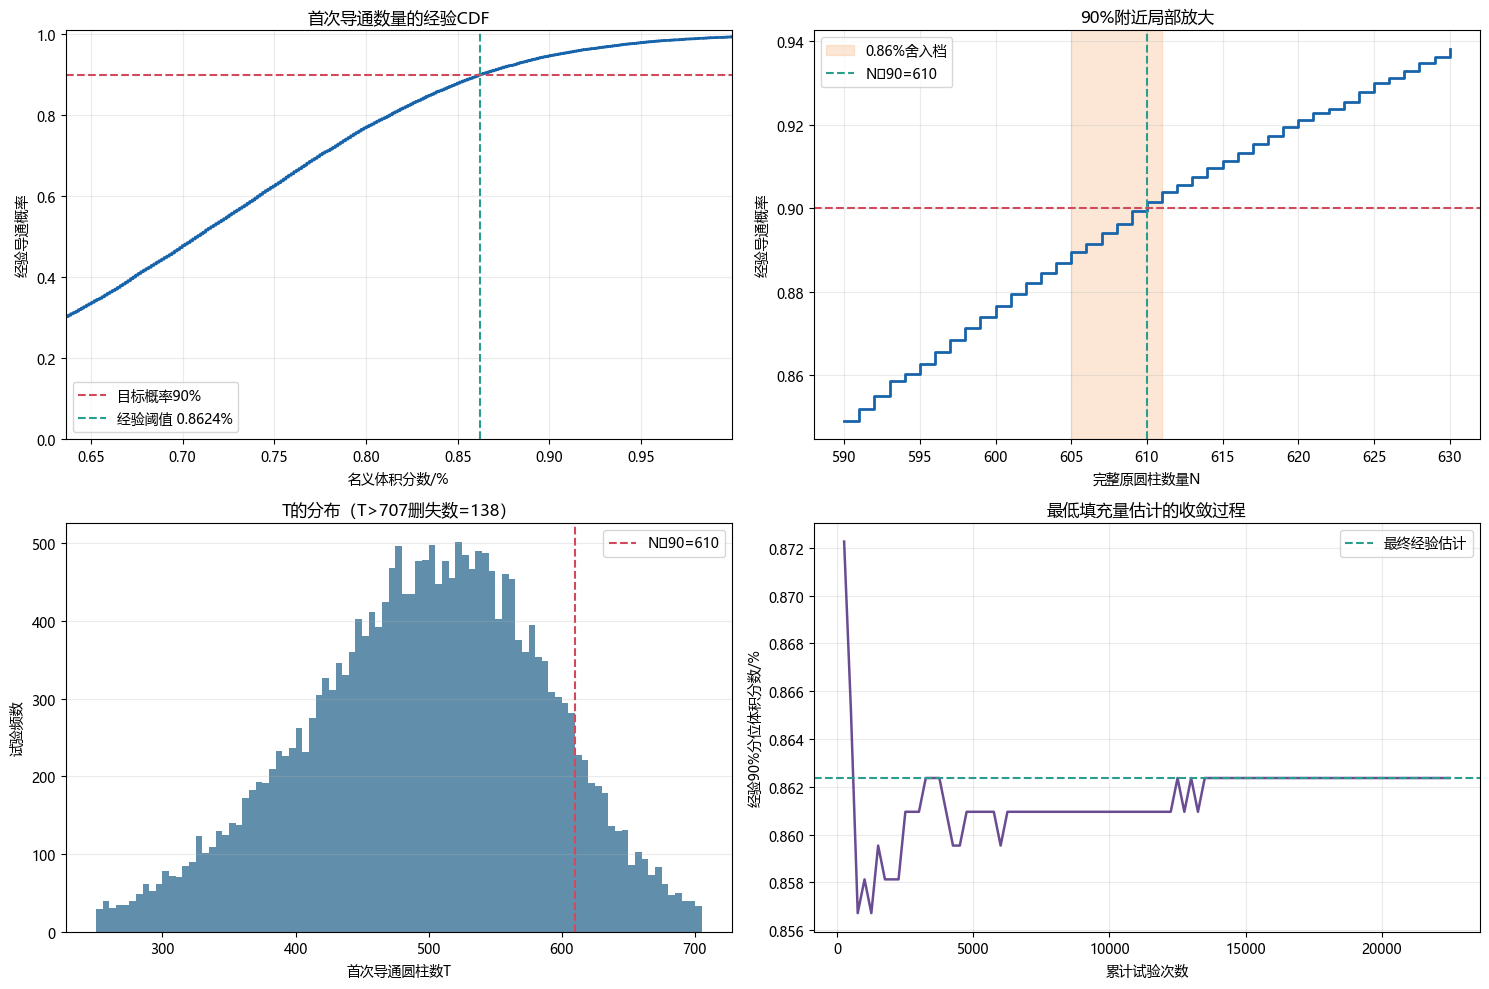

In [18]:
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
phi_axis = phi_percent(counts)

axes[0, 0].step(phi_axis, probability_curve, where="post", color="#1764ab", lw=2)
axes[0, 0].axhline(TARGET_PROBABILITY, color="#d1495b", ls="--", label="目标概率90%")
axes[0, 0].axvline(phi_hat, color="#2a9d8f", ls="--", label=f"经验阈值 {phi_hat:.4f}%")
axes[0, 0].set_xlim(phi_percent(450), phi_percent(N_MAX))
axes[0, 0].set_ylim(0, 1.01)
axes[0, 0].set_xlabel("名义体积分数/%")
axes[0, 0].set_ylabel("经验导通概率")
axes[0, 0].set_title("首次导通数量的经验CDF")
axes[0, 0].grid(alpha=0.25)
axes[0, 0].legend()

zoom = (counts >= n_hat-20) & (counts <= n_hat+20)
axes[0, 1].step(counts[zoom], probability_curve[zoom], where="post", color="#1764ab", lw=2)
axes[0, 1].axhline(TARGET_PROBABILITY, color="#d1495b", ls="--")
axes[0, 1].axvspan(candidate_low_n, candidate_high_n, color="#f4a261", alpha=0.25,
                   label=f"{candidate_report:.2f}%舍入档")
axes[0, 1].axvline(n_hat, color="#2a9d8f", ls="--", label=f"N̂90={n_hat}")
axes[0, 1].set_xlabel("完整原圆柱数量N")
axes[0, 1].set_ylabel("经验导通概率")
axes[0, 1].set_title("90%附近局部放大")
axes[0, 1].grid(alpha=0.25)
axes[0, 1].legend()

finite_t = first_passage[first_passage <= N_MAX]
bins = np.arange(max(250, int(finite_t.min())-1), N_MAX+2, 5)
axes[1, 0].hist(finite_t, bins=bins, color="#457b9d", alpha=0.85)
axes[1, 0].axvline(n_hat, color="#d1495b", ls="--", label=f"N̂90={n_hat}")
axes[1, 0].set_xlabel("首次导通圆柱数T")
axes[1, 0].set_ylabel("试验频数")
axes[1, 0].set_title(f"T的分布（T>707删失数={np.count_nonzero(first_passage==NO_HIT_SENTINEL)}）")
axes[1, 0].grid(axis="y", alpha=0.25)
axes[1, 0].legend()

checkpoints = np.unique(np.r_[np.arange(250, N_TRIALS+1, 250), N_TRIALS]).astype(int)
running_n90 = []
for m in checkpoints:
    rank = int(math.ceil(TARGET_PROBABILITY*m))
    running_n90.append(int(np.partition(first_passage[:m], rank-1)[rank-1]))
axes[1, 1].plot(checkpoints, phi_percent(running_n90), color="#6a4c93", lw=1.8)
axes[1, 1].axhline(phi_hat, color="#2a9d8f", ls="--", label="最终经验估计")
axes[1, 1].set_xlabel("累计试验次数")
axes[1, 1].set_ylabel("经验90%分位体积分数/%")
axes[1, 1].set_title("最低填充量估计的收敛过程")
axes[1, 1].grid(alpha=0.25)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 第三问结论

正式计算正在断点续算，目前完成 3100/22500 次；最终结论以固定样本量完成后的结果为准。